In [ ]:
!pip uninstall -y monai numpy opencv-python
!pip install numpy==1.26.4
!pip install monai==1.4.0
!pip install medmnist captum opencv-python

Found existing installation: monai 1.4.0
Uninstalling monai-1.4.0:
  Successfully uninstalled monai-1.4.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0,

  Using cached monai-1.4.0-py3-none-any.whl.metadata (11 kB)
Using cached monai-1.4.0-py3-none-any.whl (1.5 MB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.13.0.90-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (63.0 MB)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import medmnist
from medmnist import INFO
from torch.utils.data import DataLoader

from monai.transforms import (
    Compose, EnsureChannelFirst, Resize,
    RandFlip, RandRotate90, RandZoom
)

from captum.attr import IntegratedGradients

import matplotlib.pyplot as plt

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class MedMNIST3D:
    def __call__(self, img):
        return np.squeeze(img)

def load_medmnist_3d(flag="organmnist3d", batch_size=4, spatial_size=(64,64,64)):
    info = INFO[flag]
    DataClass = getattr(medmnist, info["python_class"])

    train_tf = Compose([
        MedMNIST3D(),
        EnsureChannelFirst(channel_dim="no_channel"),
        Resize(spatial_size),
        RandFlip(spatial_axis=[0,1,2], prob=0.5),
        RandRotate90(prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.3)
    ])

    val_tf = Compose([
        MedMNIST3D(),
        EnsureChannelFirst(channel_dim="no_channel"),
        Resize(spatial_size),
    ])

    train_ds = DataClass(split="train", transform=train_tf, download=True)
    val_ds   = DataClass(split="val", transform=val_tf, download=True)
    test_ds  = DataClass(split="test", transform=val_tf, download=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    test_loader  = DataLoader(test_ds, batch_size=1)

    return train_loader, val_loader, test_loader, info

In [ ]:
class CNN3D(nn.Module):
    def __init__(self, num_classes, input_shape=(64,64,64)):
        super().__init__()
        self.conv1 = nn.Conv3d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv3d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool3d(2)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            x = self.pool(F.relu(self.conv1(dummy)))
            x = self.pool(F.relu(self.conv2(x)))
            self.flatten_dim = x.numel()

        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, correct = 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.squeeze().long().to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return correct / total


def evaluate(model, loader):
    model.eval()
    total, correct = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.squeeze().long().to(device)

            out = model(x)
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total += x.size(0)

    return correct / total

In [ ]:
#Train
train_loader, val_loader, test_loader, info = load_medmnist_3d()

num_classes = len(info["label"])

model = CNN3D(num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = evaluate(model, val_loader)
    print(f"Epoch {epoch}: Train={tr_acc:.3f}, Val={val_acc:.3f}")

100%|██████████| 32.7M/32.7M [00:00<00:00, 73.1MB/s]


Epoch 0: Train=0.124, Val=0.168
Epoch 1: Train=0.136, Val=0.193
Epoch 2: Train=0.313, Val=0.652
Epoch 3: Train=0.473, Val=0.807
Epoch 4: Train=0.473, Val=0.702


In [ ]:
# Integrated Gradient
def compute_ig(model, x, target_class):
    model.eval()
    ig = IntegratedGradients(model)

    attr = ig.attribute(
        x,
        baselines=torch.zeros_like(x),
        target=target_class,
        n_steps=40
    )

    return attr

In [ ]:
# Counterfactual
def generate_counterfactual(x, ig, strength=0.15, mode="positive"):
    if mode == "positive":
        x_cf = x + strength * ig.sign()
    else:
        x_cf = x - strength * ig.sign()

    x_cf = torch.clamp(x_cf, 0, 1)
    return x_cf

In [ ]:
def visualize_counterfactual(volume, volume_cf, ig):
    vol = volume[0,0].cpu().numpy()
    vol_cf = volume_cf[0,0].cpu().numpy()
    ig = ig[0,0].cpu().numpy()

    d = vol.shape[0] // 2

    fig, axs = plt.subplots(1,4, figsize=(16,4))
    axs[0].imshow(vol[d], cmap="gray")
    axs[0].set_title("Original")

    axs[1].imshow(ig[d], cmap="hot")
    axs[1].set_title("Integrated Gradients")

    axs[2].imshow(vol_cf[d], cmap="gray")
    axs[2].set_title("Counterfactual")

    diff = vol_cf[d] - vol[d]
    axs[3].imshow(diff, cmap="bwr")
    axs[3].set_title("Difference")

    for ax in axs:
        ax.axis("off")

    plt.show()

In [ ]:
def run_counterfactual(model, loader, strength=0.2):
    x, y = next(iter(loader))
    x = x.to(device)

    out = model(x)
    pred = out.argmax(1).item()

    print("Original Prediction:", pred)

    ig = compute_ig(model, x, pred)

    x_cf_pos = generate_counterfactual(x, ig, strength, "positive")
    x_cf_neg = generate_counterfactual(x, ig, strength, "negative")

    with torch.no_grad():
        orig_prob = F.softmax(model(x), dim=1)
        pos_prob  = F.softmax(model(x_cf_pos), dim=1)
        neg_prob  = F.softmax(model(x_cf_neg), dim=1)

    print("Original Prob:", orig_prob)
    print("Positive CF Prob:", pos_prob)
    print("Negative CF Prob:", neg_prob)

    visualize_counterfactual(x, x_cf_pos, ig)
    visualize_counterfactual(x, x_cf_neg, ig)

Original Prediction: 10
Original Prob: metatensor([[0.0242, 0.1416, 0.2338, 0.0457, 0.0421, 0.1458, 0.0053, 0.0037, 0.0049,
         0.0758, 0.2771]], device='cuda:0')
Positive CF Prob: metatensor([[6.4640e-05, 8.9548e-02, 1.6150e-02, 1.8604e-06, 1.1318e-05, 2.6036e-04,
         9.1762e-03, 2.1621e-06, 1.4001e-05, 2.5827e-05, 8.8475e-01]],
       device='cuda:0')
Negative CF Prob: metatensor([[8.3141e-06, 4.0522e-11, 5.8131e-07, 3.0321e-09, 2.3125e-14, 4.7271e-13,
         9.9669e-01, 1.6506e-03, 1.6466e-03, 1.1459e-06, 6.5842e-17]],
       device='cuda:0')


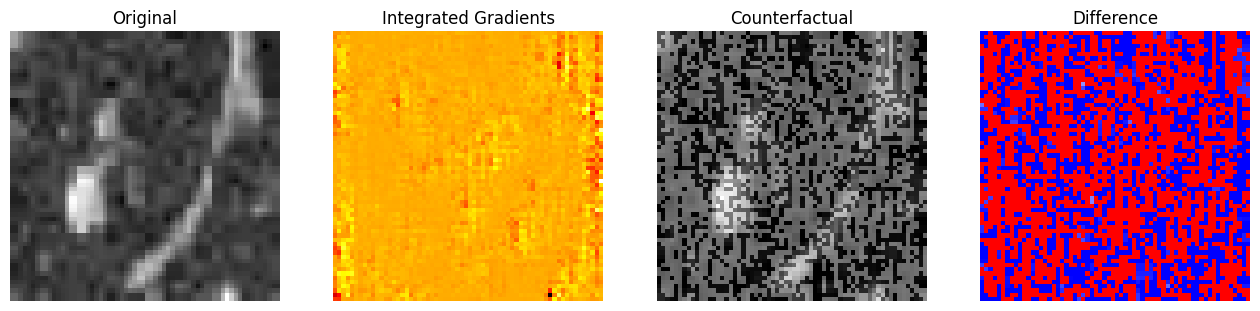

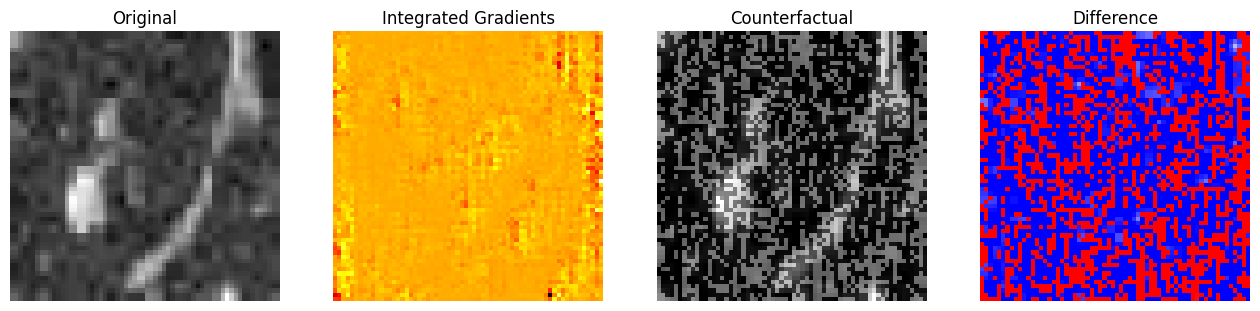

In [ ]:
run_counterfactual(model, test_loader)

In [ ]:
#Grad CAM 3D
import torch
import torch.nn.functional as F

class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.zero_grad()
        output = self.model(x)
        loss = output[:, class_idx]
        loss.backward()

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2,3,4), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[2:], mode='trilinear', align_corners=False)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

In [ ]:
# Last conv layer
gradcam = GradCAM3D(model, model.conv2)
gradcam

In [ ]:
#GradCAM ++ 3D
class GradCAMPlusPlus3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.zero_grad()
        output = self.model(x)
        loss = output[:, class_idx]
        loss.backward()

        grads = self.gradients
        acts = self.activations

        grads_power_2 = grads ** 2
        grads_power_3 = grads ** 3

        alpha = grads_power_2 / (2 * grads_power_2 + acts * grads_power_3 + 1e-8)
        weights = (alpha * F.relu(grads)).sum(dim=(2,3,4), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[2:], mode='trilinear', align_corners=False)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

In [ ]:
#Visualize GradCam 3D
def show_cam(volume, cam, title):
    vol = volume[0,0].cpu().numpy()
    d = vol.shape[0] // 2

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(vol[d], cmap="gray")
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(vol[d], cmap="gray")
    plt.imshow(cam[d], cmap="jet", alpha=0.5)
    plt.title(title)

    plt.show()

In [ ]:
# Run GradCam & GradCam ++
def run_gradcams(model, loader):
    x, y = next(iter(loader))
    x = x.to(device)

    output = model(x)
    pred = output.argmax(1).item()

    gradcam = GradCAM3D(model, model.conv2)
    cam = gradcam.generate(x, pred)

    gradcampp = GradCAMPlusPlus3D(model, model.conv2)
    campp = gradcampp.generate(x, pred)

    show_cam(x, cam, "GradCAM 3D")
    show_cam(x, campp, "GradCAM++ 3D")

    return cam, campp

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


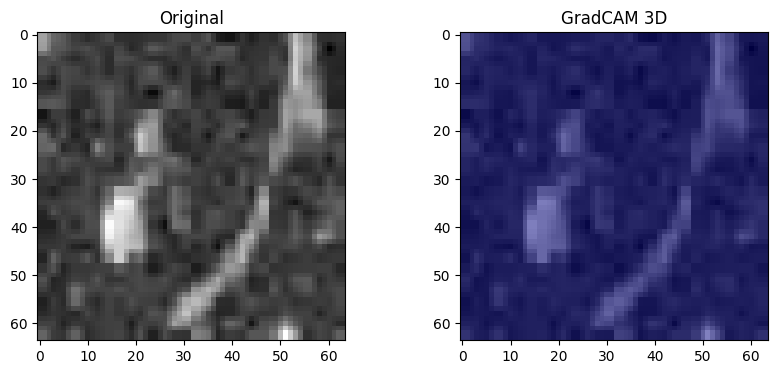

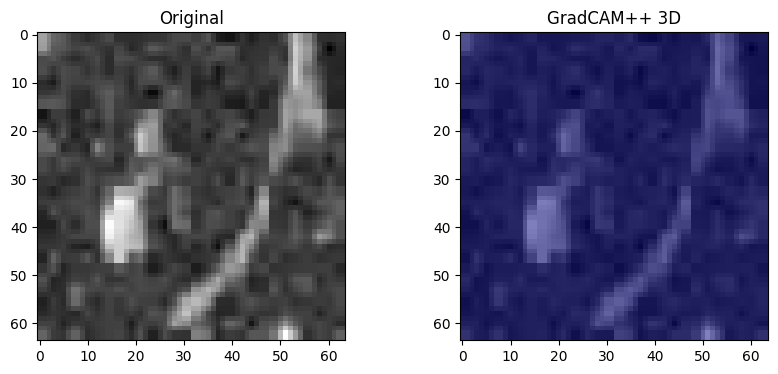

In [ ]:
cam, campp = run_gradcams(model, test_loader)

In [ ]:
def generate_prediction_explanation(pred_class, ig, cam, campp):
    ig_importance = ig.abs().mean().item()
    cam_importance = cam.mean()
    campp_importance = campp.mean()

    explanation = "Prediction Explanation:\n"

    explanation += "The prediction is influenced by regions highlighted by Integrated Gradients and GradCAM methods. "

    if ig_importance > 0.02:
        explanation += "Sharp intensity changes and structural boundaries are important features. "

    if cam_importance > 0.3:
        explanation += "The model focuses on tumor boundary and shape features. "

    if campp_importance > 0.3:
        explanation += "GradCAM++ indicates important fine-grained regions such as tumor edges and internal texture. "

    explanation += "\nCounterfactual analysis shows that increasing these highlighted regions increases the probability of the predicted class, while decreasing them reduces confidence and may flip the prediction."

    return explanation

In [ ]:
def full_xai_pipeline(model, test_loader):
    x, y = next(iter(test_loader))
    x = x.to(device)

    output = model(x)
    pred = output.argmax(1).item()

    print("Prediction:", pred)

    # Integrated Gradients
    ig = compute_ig(model, x, pred)

    # Counterfactual
    x_cf_pos = generate_counterfactual(x, ig, 0.2, "positive")
    x_cf_neg = generate_counterfactual(x, ig, 0.2, "negative")

    # GradCAM
    gradcam = GradCAM3D(model, model.conv2)
    cam = gradcam.generate(x, pred)

    gradcampp = GradCAMPlusPlus3D(model, model.conv2)
    campp = gradcampp.generate(x, pred)

    # Explanation text
    explanation = generate_prediction_explanation(pred, ig, cam, campp)
    print("\n", explanation)

    show_cam(x, cam, "GradCAM")
    show_cam(x, campp, "GradCAM++")
    visualize_counterfactual(x, x_cf_pos, ig)
    visualize_counterfactual(x, x_cf_neg, ig)

Prediction: 10

 Prediction Explanation:
The prediction is influenced by regions highlighted by Integrated Gradients and GradCAM methods. 
Counterfactual analysis shows that increasing these highlighted regions increases the probability of the predicted class, while decreasing them reduces confidence and may flip the prediction.


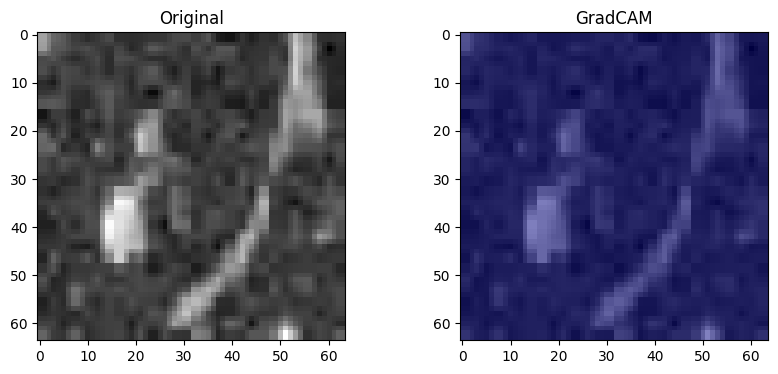

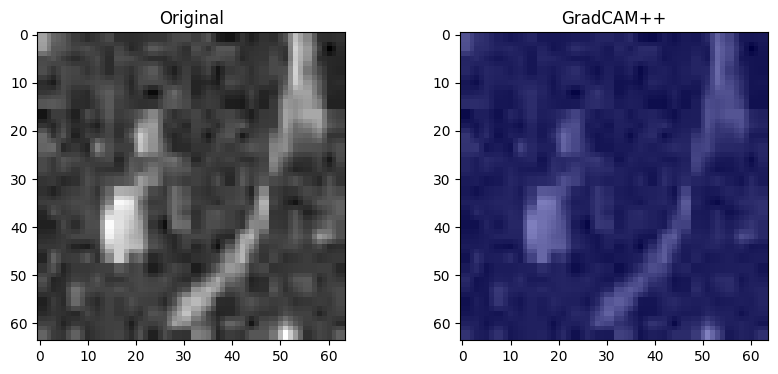

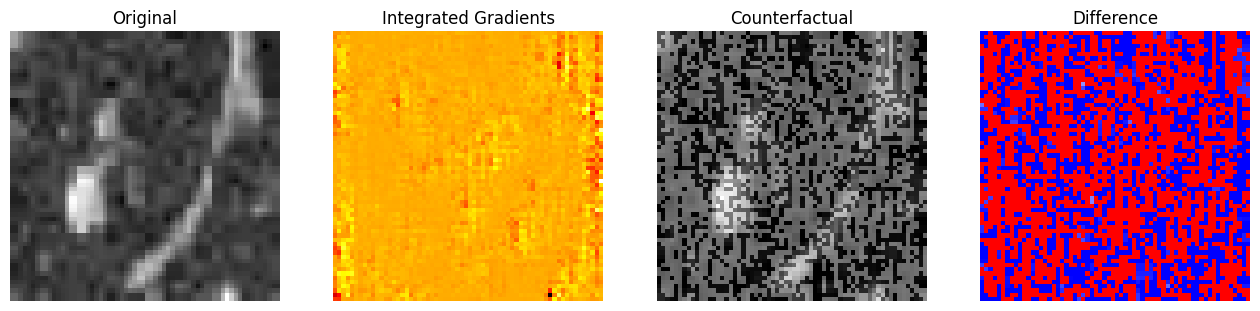

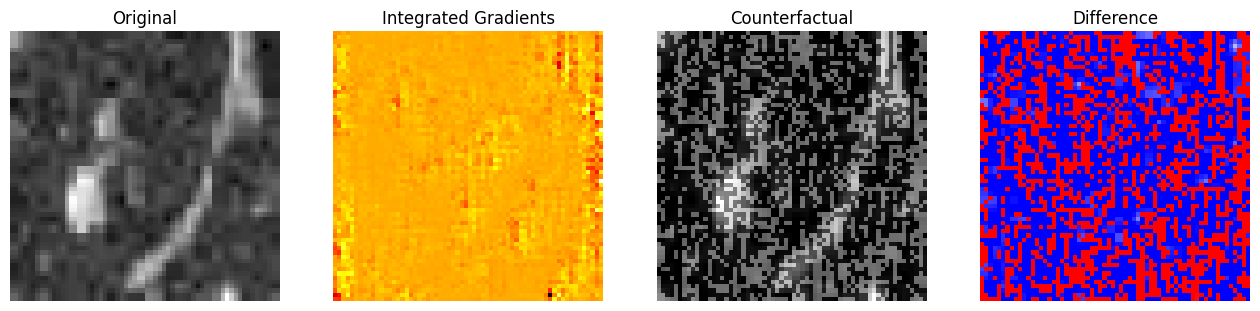

In [ ]:
full_xai_pipeline(model, test_loader)